In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.distances import smets_distance

In [6]:
# Functions for visualization details of SMETS components (not part of sktime, just for reference)

def uts_distance(a, b):
    """
    Distance between two univariate time series (L2).
    a, b: 1D numpy arrays with the same length.
    """
    return np.linalg.norm(a - b)


def entropy_of_series(x, bins=20):
    """
    Approximate entropy H(x) using a histogram.
    x: 1D numpy array.
    bins: number of histogram bins.
    """
    hist, _ = np.histogram(x, bins=bins, density=False)
    p = hist.astype(float) / (hist.sum() + 1e-12)
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log(p))


def smets_details_reference(mts1, mts2, p_norm=2):
    """
    Reference SMETS implementation used to generate intermediate visualization details.

    mts1, mts2: list of 1D numpy arrays (each is one variable / dimension).
    p_norm: p in L_p norm (usually 1 or 2).
    """
    d1 = len(mts1)
    d2 = len(mts2)

    # ----- Step 1: pairwise UTS distance matrix -----
    dist_matrix = np.zeros((d1, d2))
    for i in range(d1):
        for j in range(d2):
            dist_matrix[i, j] = uts_distance(mts1[i], mts2[j])

    # Greedy matching of the closest pairs
    matched_dists = []
    matched_pairs = []
    used_i = set()
    used_j = set()
    num_pairs = min(d1, d2)

    for _ in range(num_pairs):
        tmp = dist_matrix.copy()
        for i in used_i:
            tmp[i, :] = np.inf
        for j in used_j:
            tmp[:, j] = np.inf

        i_min, j_min = np.unravel_index(np.argmin(tmp), tmp.shape)
        used_i.add(i_min)
        used_j.add(j_min)
        matched_pairs.append((i_min, j_min))
        matched_dists.append(dist_matrix[i_min, j_min])

    d_vec = np.array(matched_dists)

    # ----- Step 2: partial matching distance (L_p over matched pairs) -----
    if len(d_vec) > 0:
        norm_d = np.sum(np.abs(d_vec) ** p_norm) ** (1.0 / p_norm)
    else:
        norm_d = 0.0

    # ----- Step 3: penalties for unmatched components -----
    unmatched1 = [i for i in range(d1) if i not in used_i]
    unmatched2 = [j for j in range(d2) if j not in used_j]

    unmatched_series = [mts1[i] for i in unmatched1] + [mts2[j] for j in unmatched2]

    # Entropy-based penalty EP
    if len(unmatched_series) > 0:
        entropies = [entropy_of_series(x) for x in unmatched_series]
        EP = np.mean(entropies)
    else:
        EP = 0.0

    # Dimensional difference penalty P
    d_max = max(d1, d2)
    d_min = min(d1, d2)
    if d_max + d_min > 0:
        P = (d_max - d_min) / (d_max + d_min)
    else:
        P = 0.0

    # Final SMETS distance (reference)
    d_smets_ref = np.sqrt((norm_d + EP) ** 2 + P ** 2)

    details = {
        "dist_matrix": dist_matrix,
        "matched_pairs": matched_pairs,
        "matched_dists": matched_dists,
        "unmatched1": unmatched1,
        "unmatched2": unmatched2,
        "norm_d": norm_d,
        "EP": EP,
        "P": P,
        "d_smets_ref": d_smets_ref,
    }
    return details


def visualize_smets(mts1, mts2, name1, name2, t, uts_metric="linear", p_norm=2):
    """
    Compute SMETS distance with sktime and produce several visualizations:
    1) Distance matrix heatmap
    2) Matched pairs overlay plots
    3) Unmatched components
    4) Bar chart for norm_d, EP, P, d_SMETS

    Notes
    -----
    - Final SMETS distance is computed by sktime.distances.smets_distance.
    - Intermediate details for visualization are produced by a local reference helper.
    """
    info = smets_details_reference(mts1, mts2, p_norm=p_norm)

    # Use sktime implementation as the authoritative distance
    x = np.vstack(mts1)
    y = np.vstack(mts2)
    d_smets = smets_distance(
        x,
        y,
        p_norm=p_norm,
        uts_metric=uts_metric,
    )

    dist_matrix = info["dist_matrix"]
    matched_pairs = info["matched_pairs"]
    matched_dists = info["matched_dists"]
    unmatched1 = info["unmatched1"]
    unmatched2 = info["unmatched2"]
    norm_d = info["norm_d"]
    EP = info["EP"]
    P = info["P"]
    d_smets_ref = info["d_smets_ref"]

    print(f"=== {name1} vs {name2} ===")
    print(f"UTS metric used by SMETS: {uts_metric}")
    print("Matched pairs (dim in mts1, dim in mts2, distance):")
    for (i, j), d in zip(matched_pairs, matched_dists):
        print(f"  ({i}, {j})  dist = {d:.4f}")
    print(f"Unmatched dims in {name1}: {unmatched1}")
    print(f"Unmatched dims in {name2}: {unmatched2}")
    print(f"||d||_p = {norm_d:.4f}, EP = {EP:.4f}, P = {P:.4f}")
    print(f"SMETS distance        = {d_smets:.4f}")
    print()

    # ---- 1) Heatmap of pairwise distances ----
    plt.figure(figsize=(5, 4))
    plt.imshow(dist_matrix, cmap="viridis")
    plt.colorbar(label="UTS distance")
    plt.xlabel(f"{name2} dimension index")
    plt.ylabel(f"{name1} dimension index")
    plt.title(f"Pairwise UTS distance: {name1} vs {name2}")
    plt.xticks(range(len(mts2)))
    plt.yticks(range(len(mts1)))
    plt.tight_layout()
    plt.show()

    # ---- 2) Plots of matched pairs ----
    if len(matched_pairs) > 0:
        n_pairs = len(matched_pairs)
        plt.figure(figsize=(6, 2.5 * n_pairs))
        for k, ((i, j), d) in enumerate(zip(matched_pairs, matched_dists), start=1):
            ax = plt.subplot(n_pairs, 1, k)
            ax.plot(t, mts1[i], label=f"{name1}[{i}]")
            ax.plot(t, mts2[j], label=f"{name2}[{j}]")
            ax.set_title(f"Matched pair {k}: {name1}[{i}] vs {name2}[{j}], dist={d:.4f}")
            ax.grid(True)
            ax.legend()
        plt.tight_layout()
        plt.show()

    # ---- 3) Unmatched components ----
    if len(unmatched1) + len(unmatched2) > 0:
        n_unmatched = len(unmatched1) + len(unmatched2)
        plt.figure(figsize=(6, 2.5 * n_unmatched))
        idx = 1
        for i in unmatched1:
            ax = plt.subplot(n_unmatched, 1, idx)
            ax.plot(t, mts1[i], label=f"{name1}[{i}] (unmatched)")
            ax.set_title(f"Unmatched dim in {name1}: index {i}")
            ax.grid(True)
            ax.legend()
            idx += 1
        for j in unmatched2:
            ax = plt.subplot(n_unmatched, 1, idx)
            ax.plot(t, mts2[j], label=f"{name2}[{j}] (unmatched)")
            ax.set_title(f"Unmatched dim in {name2}: index {j}")
            ax.grid(True)
            ax.legend()
            idx += 1
        plt.tight_layout()
        plt.show()

    # ---- 4) Bar chart of components of SMETS ----
    plt.figure(figsize=(5, 4))
    components = ["||d||_p", "EP", "P", "d_SMETS"]
    values = [norm_d, EP, P, d_smets]
    plt.bar(components, values)
    plt.title(
        f"SMETS components: {name1} vs {name2}\n"
        f"d_SMETS = {d_smets:.4f}"
    )
    for x, v in zip(components, values):
        plt.text(x, v, f"{v:.2f}", ha="center", va="bottom")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

In [7]:
# ---------- 2. Generate 3 MTS with clear visual similarity ----------

np.random.seed(0)
T = 200
t = np.linspace(0, 4 * np.pi, T)

# Base patterns
base1 = np.sin(t)                 # smooth sine
base2 = np.cos(t)                 # cosine
base3 = np.sin(2 * t)             # higher frequency

# mts1: 3-dimensional MTS
mts1 = [
    base1 + 0.05 * np.random.randn(T),
    base2 + 0.05 * np.random.randn(T),
    base3 + 0.05 * np.random.randn(T)
]

# mts2: 4-dimensional MTS, first two dims similar to mts1[0] and mts1[1]
mts2 = [
    base1 + 0.05 * np.random.randn(T),         # similar to mts1[0]
    base2 + 0.05 * np.random.randn(T),         # similar to mts1[1]
    np.sin(t + 0.5) + 0.10 * np.random.randn(T),
    0.5 * base3 + 0.10 * np.random.randn(T)
]

# mts3: 2-dimensional MTS, quite different (random walk)
rw1 = np.cumsum(0.2 * np.random.randn(T))
rw2 = np.cumsum(0.2 * np.random.randn(T))
mts3 = [rw1, rw2]

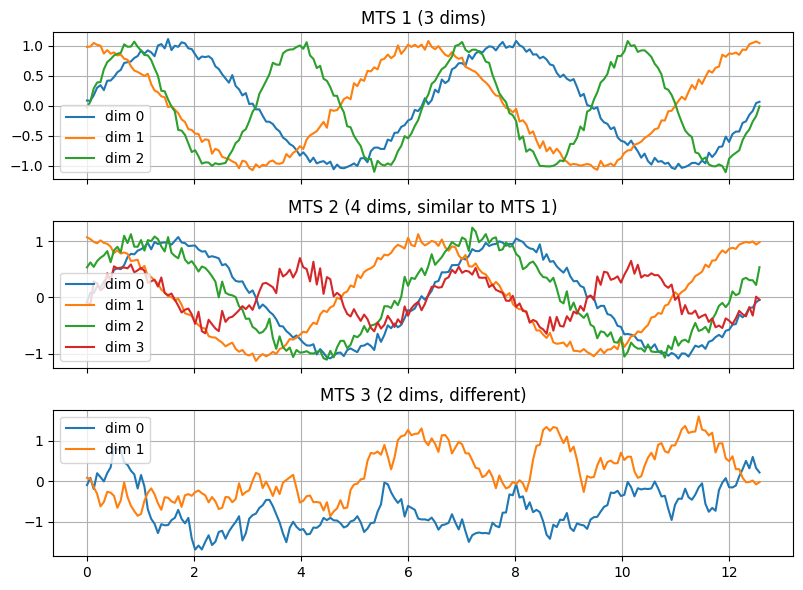

=== MTS1 vs MTS2 ===
UTS metric used by SMETS: linear
Matched pairs (dim in mts1, dim in mts2, distance):
  (1, 1)  dist = 0.9704
  (0, 0)  dist = 1.0201
  (2, 3)  dist = 5.2847
Unmatched dims in MTS1: []
Unmatched dims in MTS2: [2]
||d||_p = 5.4690, EP = 2.9005, P = 0.1429
SMETS distance        = 8.3707



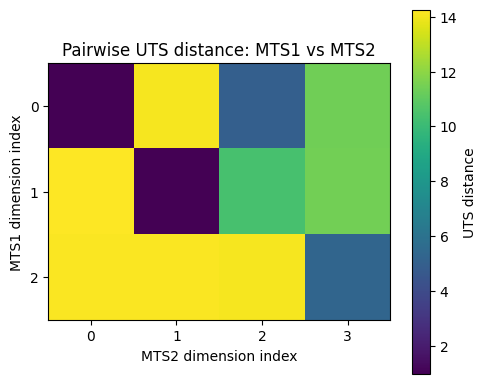

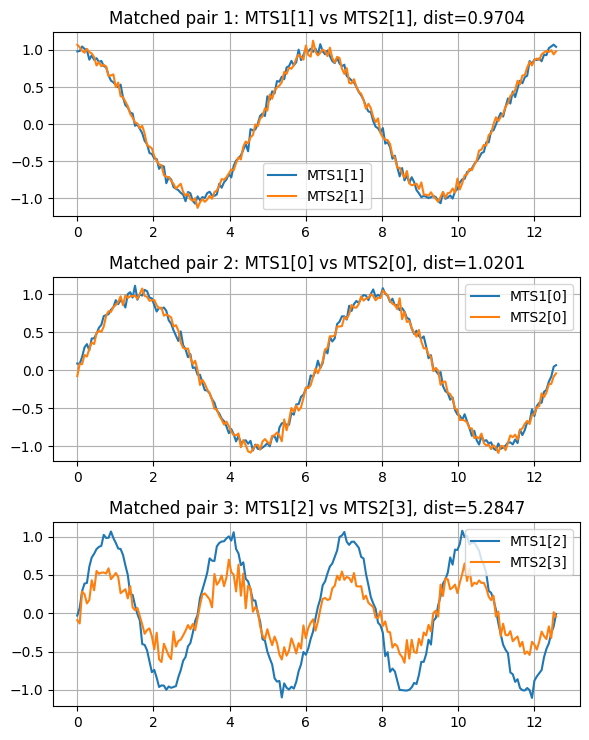

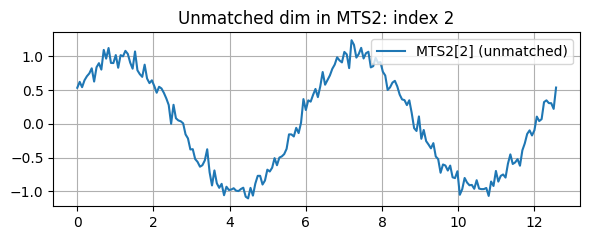

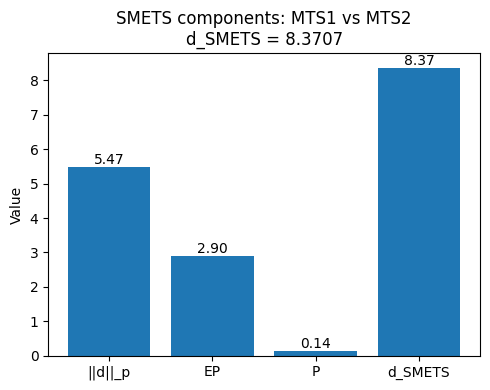

=== MTS1 vs MTS3 ===
UTS metric used by SMETS: linear
Matched pairs (dim in mts1, dim in mts2, distance):
  (1, 1)  dist = 12.4545
  (2, 0)  dist = 15.2077
Unmatched dims in MTS1: [0]
Unmatched dims in MTS3: []
||d||_p = 19.6567, EP = 2.8967, P = 0.2000
SMETS distance        = 22.5543



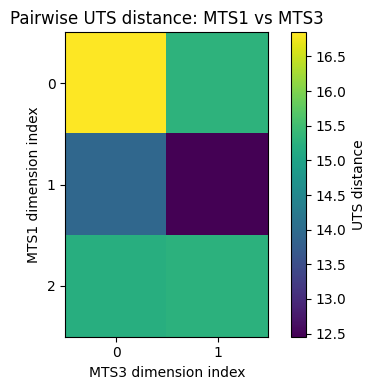

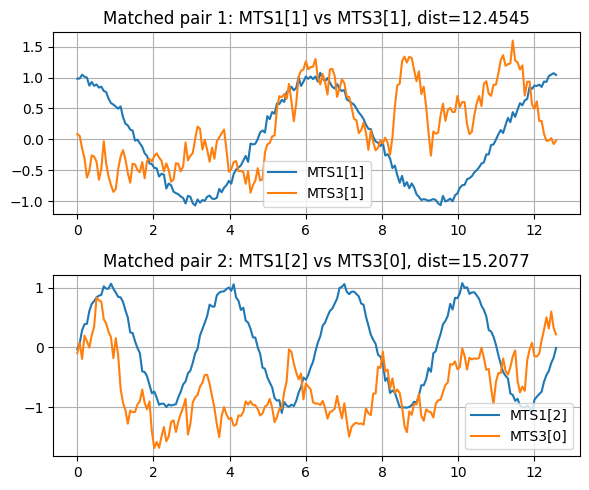

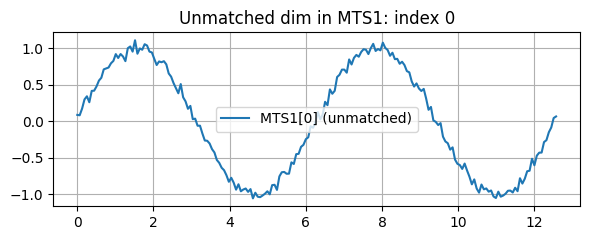

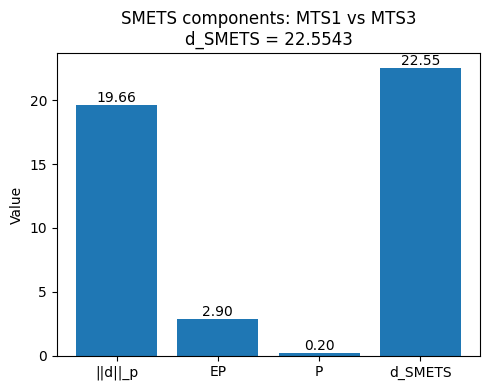

=== MTS2 vs MTS3 ===
UTS metric used by SMETS: linear
Matched pairs (dim in mts1, dim in mts2, distance):
  (3, 1)  dist = 11.7130
  (1, 0)  dist = 13.9716
Unmatched dims in MTS2: [0, 2]
Unmatched dims in MTS3: []
||d||_p = 18.2319, EP = 2.9110, P = 0.3333
SMETS distance        = 21.1455



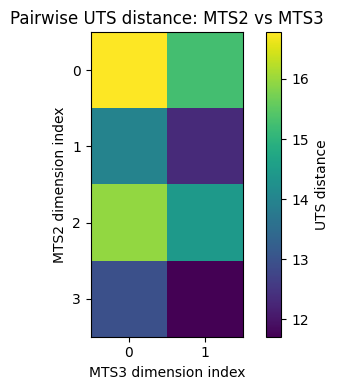

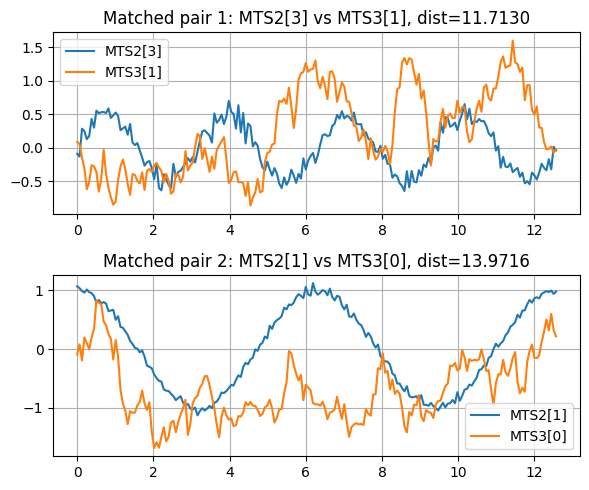

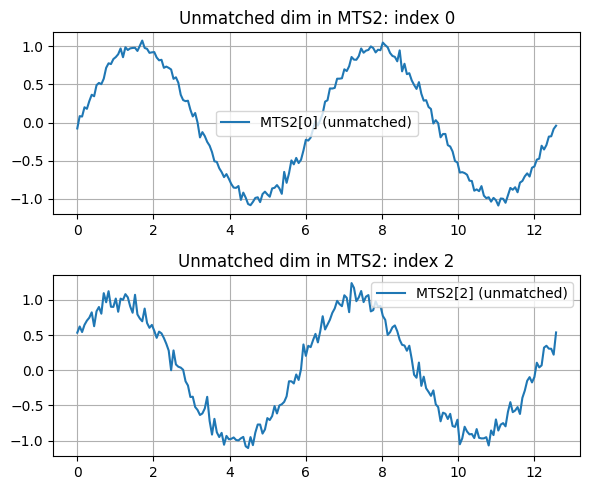

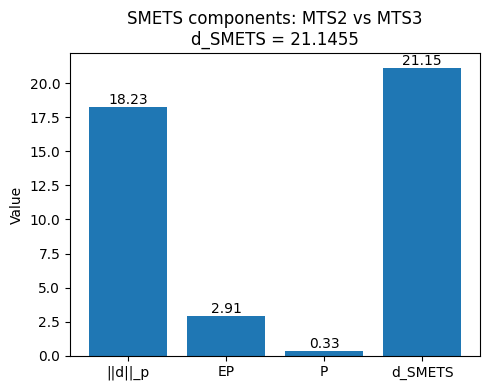


Now using uts_metric='squared'

=== MTS1 vs MTS2 ===
UTS metric used by SMETS: squared
Matched pairs (dim in mts1, dim in mts2, distance):
  (1, 1)  dist = 0.9704
  (0, 0)  dist = 1.0201
  (2, 3)  dist = 5.2847
Unmatched dims in MTS1: []
Unmatched dims in MTS2: [2]
||d||_p = 5.4690, EP = 2.9005, P = 0.1429
SMETS distance        = 30.8637



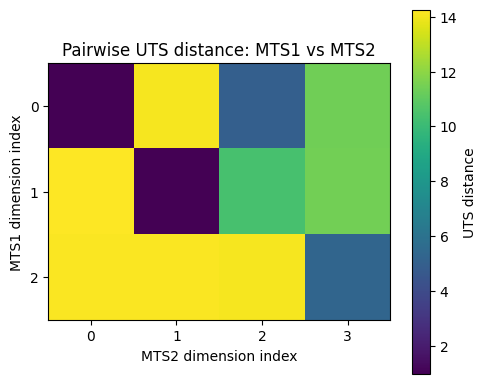

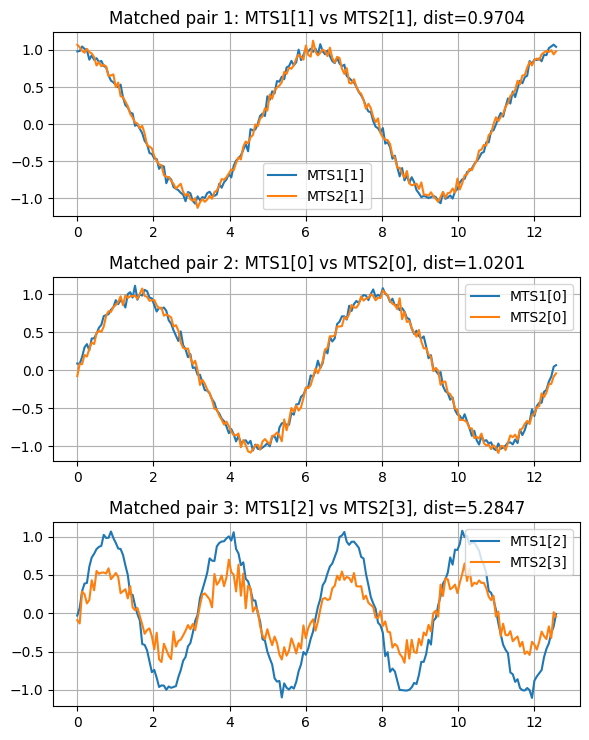

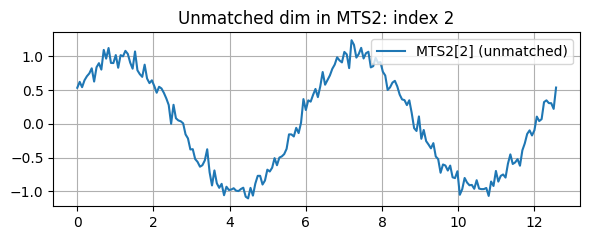

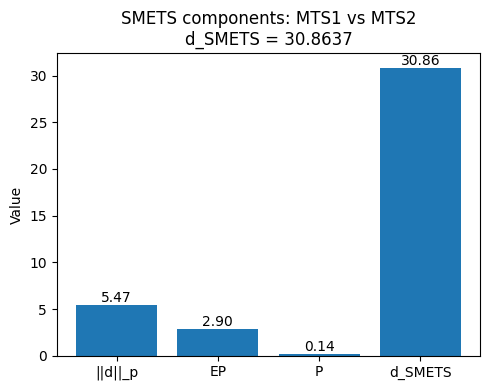

In [8]:
# ---------- 3. Visualize the three MTS ----------

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
titles = ["MTS 1 (3 dims)", "MTS 2 (4 dims, similar to MTS 1)", "MTS 3 (2 dims, different)"]
all_mts = [mts1, mts2, mts3]

for ax, mts, title in zip(axes, all_mts, titles):
    for idx, ts in enumerate(mts):
        ax.plot(t, ts, label=f"dim {idx}")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

# ---------- 4. Compute distances with full visualization ----------

# default: uts_metric="linear" (same as euclidean in sktime implementation)
visualize_smets(mts1, mts2, "MTS1", "MTS2", t, uts_metric="linear")
visualize_smets(mts1, mts3, "MTS1", "MTS3", t, uts_metric="linear")
visualize_smets(mts2, mts3, "MTS2", "MTS3", t, uts_metric="linear")

# ---------- 5. Optional: switch inner UTS metric dynamically ----------

print("\nNow using uts_metric='squared'\n")
visualize_smets(mts1, mts2, "MTS1", "MTS2", t, uts_metric="squared")